
Importing the required Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.model_selection import KFold
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


Loading the dataframe

In [3]:
missing_val = '?'
df = pd.read_csv('adult.csv',na_values = missing_val)

We can see that missing values are present in the form of "?" in "workclass","occupation", "native.country" so we are replacing it with NaN (not a null) for identifying them as missing value for further analysis


Viewing the dataset

In [4]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [5]:
df.tail()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32560,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [6]:
df.shape

(32561, 15)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  31978 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.2 MB


Observation :

In above using 'info' function we found that there is missing values in Dataset which was represented by '?' and in starting when loading the data set we converted the value '?' to null value ('NaN').
And this info function states data type of each columns it has. In this Dataset there is only 2 data type i.e. int and object.

In [8]:
df.drop('fnlwgt',axis=1,inplace=True)
df.head()

,age,workclass,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


Columns with atleast one missing value :

In [9]:
df.isnull().any(axis=0)

age               False
workclass          True
education         False
education.num     False
marital.status    False
occupation         True
relationship      False
race              False
sex               False
capital.gain      False
capital.loss      False
hours.per.week    False
native.country     True
income            False
dtype: bool

Observation :

df.isnull() - It returns True if values are missing,In above we can say there are 3 columns contain missing values i.e., 'workclass', 'occupation', 'native.country'. In this where the data contain missing values has been shown using True and reset that doesn't contain missing values are represented as False.

Identifying missing values in columns :

In [10]:
df.isnull().sum()

age                  0
workclass         1836
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

Observation :

In above we can say that in 'workclass' there are 1836 missing values followed by 'occupation' having missing values 1843 and 'native.country' having missing values 583.

In [11]:
df.loc[df['workclass'].isnull()==True,['workclass','occupation','native.country']]

,workclass,occupation,native.country
0,NaN,NaN,United-States
2,NaN,NaN,United-States
14,NaN,NaN,United-States
24,NaN,NaN,United-States
44,NaN,NaN,United-States
...,...,...,...
32533,NaN,NaN,United-States
32534,NaN,NaN,United-States
32541,NaN,NaN,United-States
32543,NaN,NaN,United-States


Observation of pattern towards the missing value :

We can see that the Workclass and occupation having the missing value of the Individuals who are from United sates
And the occupation have missing value where the workclass is empty.

Treating Missing values in Dataset :

Percentage of rows that were removed while handling missing values :

In [12]:
le = round((1-(len(df.dropna())/len(df)))*100,2)
print('The Percentage of Rows that were removed while handling missing values : {0} %'.format(le))

The Percentage of Rows that were removed while handling missing values : 7.37 %


Pandas Dropna function :

In [13]:
df.dropna(inplace = True)

In [14]:
male = (df[df.sex == "Male"].sex.value_counts().values[0]/df.shape[0])*100
female = (df[df.sex == "Female"].sex.value_counts().values[0]/df.shape[0])*100
print('Percentage of Male is : %d %%' % round(male))
print('Percentage of Female is : %d %%' % round(female))


Percentage of Male is : 68 %
Percentage of Female is : 32 %


Observation :

We can look through the above analysis and state that there are 68% of Male Individuals and 32% of Female Individuals.

Pandas Describe :

In [15]:
df.describe(include='number')

,age,education.num,capital.gain,capital.loss,hours.per.week
count,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000
mean,38.437902,10.121312,1092.007858,88.372489,40.931238
std,13.134665,2.549995,7406.346497,404.298370,11.979984
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,47.000000,13.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


In [16]:
df.describe(include=["O"])

C:\Users\Asus\AppData\Local\Temp\ipykernel_7496\367955815.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=["O"])


,workclass,education,marital.status,occupation,relationship,race,sex,native.country,income
count,30162,30162,30162,30162,30162,30162,30162,30162,30162
unique,7,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22286,9840,14065,4038,12463,25933,20380,27504,22654


Observation :

the above function tells that the dataset has 10 numerical columns and 4 categorical columns.

Exploratory Data Analysis :

(A.) Univariate Analysis :

-- CountPlot :

In Countplot for each categorial variable, Y-axis represent the no. of counts each type in variable , and X-axis represent the Type in variables.

C:\Users\Asus\AppData\Local\Temp\ipykernel_7496\2163835304.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(x='workclass', data=df, palette="Set3")


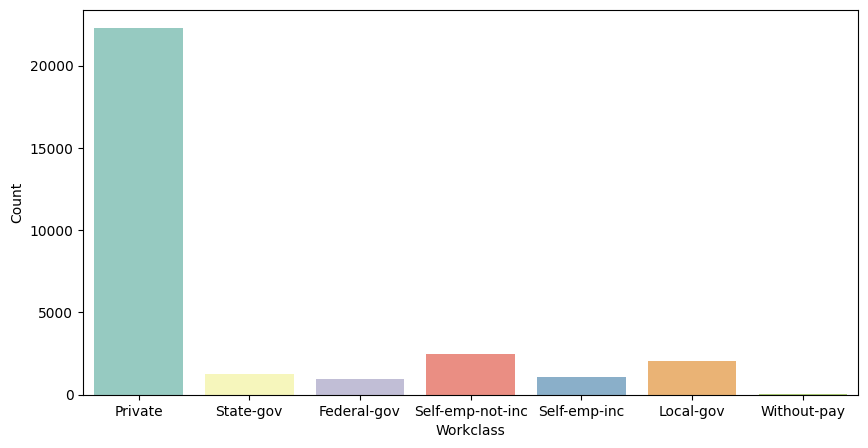

In [21]:
### Workclass
plt.figure(figsize=(10,5))
sb.countplot(x='workclass', data=df, palette="Set3")
plt.xticks(rotation=0)
plt.ylabel("Count")
plt.xlabel("Workclass")
plt.show()